# Image segmentation using Pretrained U-Net

### Imports

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import torch
import torchvision.transforms as transforms
from PIL import Image

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)
model = smp.DeepLabV3(
    encoder_name='resnext101_32x32d',
    encoder_weights='instagram',
    classes=5,
    in_channels=3,
    activation='sigmoid'
).to(DEVICE)
_ = model.eval()

cuda


In [4]:
def get_img_with_arr(img_path, as_binary=False):
    img_original = Image.open(img_path).convert('RGB')# Convert to RGB to avoid 4 channel problems
    img_original_arr = np.array(img_original)
    if(as_binary):
        img_original_arr = img_original.convert('1')
    return (img_original, img_original_arr)


In [7]:
img, _ = get_img_with_arr('../imagenes/object_detection/car2.png')

transform = transforms.Compose([
    transforms.Resize((1536, 1536)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img_tensor = transform(img)

img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

In [8]:
images_pred = []
with torch.no_grad():
    pred = model(img_tensor)
    total_classes = len(pred[0])
    # img_pred = pred[0][0].cpu().numpy()
    for i in range(total_classes):
        images_pred.append(pred[0][i].cpu().numpy())

In [9]:
masks = []
for i in range(total_classes):
    masks.append((images_pred[i] > 0.85).astype(np.uint8))

#mask = (img_pred > 0.9).astype(np.uint8)
#print(mask)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


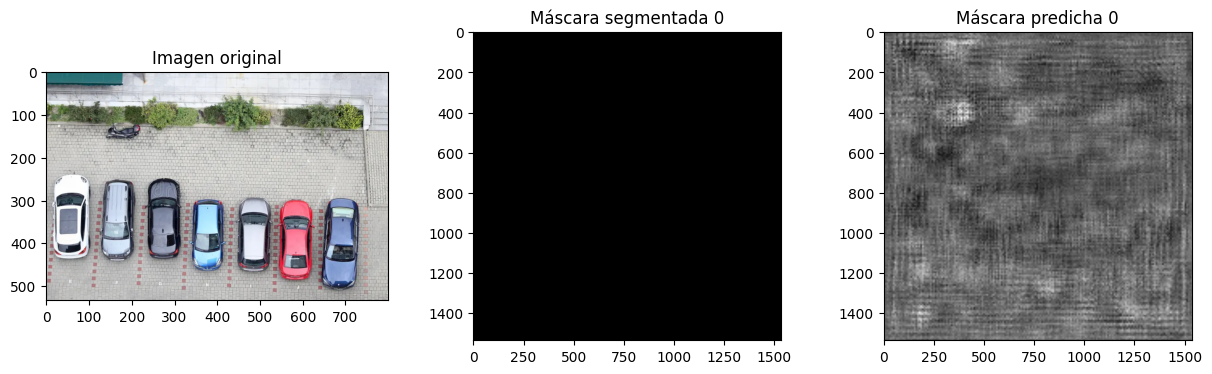

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


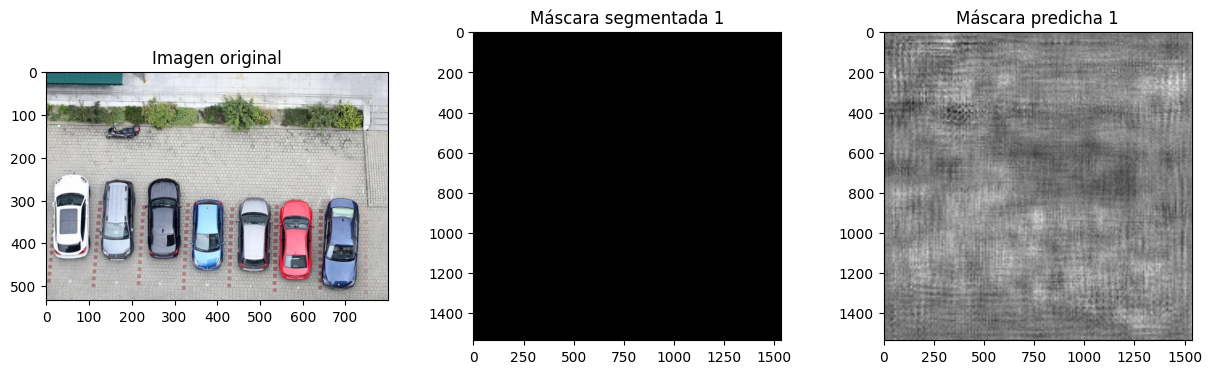

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


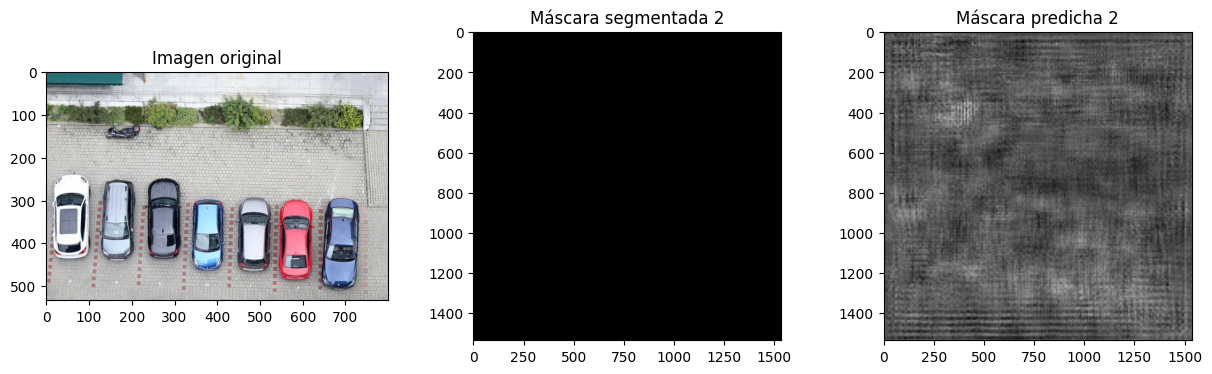

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


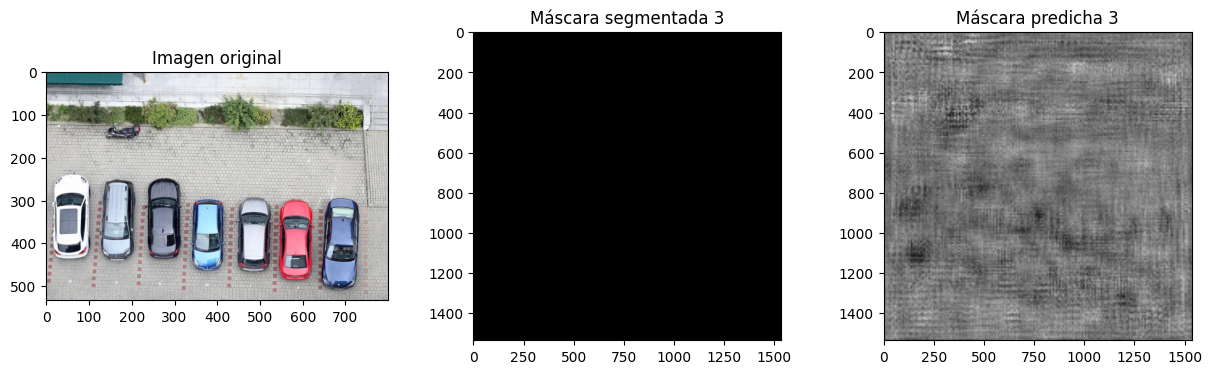

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


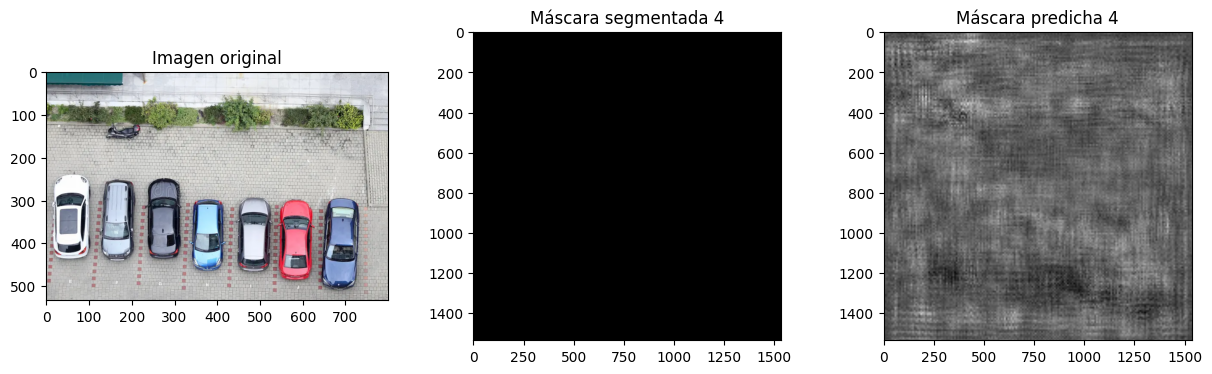

In [10]:
for i in range(total_classes):
    print(masks[i] > 0)
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.title("Imagen original")
    plt.imshow(img)
    plt.subplot(1,3,2)
    plt.title(f"Máscara segmentada {i}")
    plt.imshow(masks[i], cmap='gray')
    plt.subplot(1,3,3)
    plt.title(f"Máscara predicha {i}")
    plt.imshow(images_pred[i], cmap='gray')
    plt.show()